In [2]:
import pandas as pd
import numpy as np

print("Credit Risk Model Development")
print("Environment ready!")

Credit Risk Model Development
Environment ready!


In [3]:
# Synthetic Credit Risk Dataset
# Created for model development and demonstration purposes

np.random.seed(42)

n = 2000

data = pd.DataFrame({
    "income": np.random.normal(60000, 20000, n).clip(15000, 150000),
    "age": np.random.randint(21, 65, n),
    "credit_score": np.random.normal(680, 70, n).clip(300, 850),
    "loan_amount": np.random.normal(25000, 12000, n).clip(5000, 80000),
    "existing_debt": np.random.normal(15000, 10000, n).clip(0, 60000),
    "employment_years": np.random.randint(0, 30, n),
    "late_payments": np.random.poisson(1, n)
})

data.head()

,income,age,credit_score,loan_amount,existing_debt,employment_years,late_payments
0,69934.283060,50,742.506771,13984.286745,12168.481151,3,2
1,57234.713977,51,808.073414,45774.035581,0.000000,23,1
2,72953.770762,58,651.321939,17375.081437,16580.938986,25,2
3,90460.597128,31,729.862551,24504.487756,15334.434680,6,1
4,55316.932506,55,839.715629,31672.265162,14181.056204,13,2


In [4]:
# Create a synthetic default-risk score

risk_score = (
    -0.004 * (data["credit_score"] - 650)
    + 0.00002 * data["loan_amount"]
    + 0.00002 * data["existing_debt"]
    - 0.00001 * data["income"]
    + 0.30 * data["late_payments"]
    - 0.03 * data["employment_years"]
)

# Convert risk score into probability
default_probability = 1 / (1 + np.exp(-risk_score))

# Generate binary default outcome
data["default"] = np.random.binomial(
    1,
    default_probability
)

data.head()

,income,age,credit_score,loan_amount,existing_debt,employment_years,late_payments,default
0,69934.283060,50,742.506771,13984.286745,12168.481151,3,2,1
1,57234.713977,51,808.073414,45774.035581,0.000000,23,1,0
2,72953.770762,58,651.321939,17375.081437,16580.938986,25,2,0
3,90460.597128,31,729.862551,24504.487756,15334.434680,6,1,0
4,55316.932506,55,839.715629,31672.265162,14181.056204,13,2,1


In [5]:
print("Default distribution:")
print(data["default"].value_counts())

print("\nDefault rate:")
print(data["default"].mean())

Default distribution:
default
0    1038
1     962
Name: count, dtype: int64

Default rate:
0.481


In [6]:
#missing values and duplicates 
# Data Quality Assessment

print("Dataset shape:", data.shape)

print("\nMissing values:")
print(data.isnull().sum())

print("\nDuplicate rows:", data.duplicated().sum())

Dataset shape: (2000, 8)

Missing values:
income              0
age                 0
credit_score        0
loan_amount         0
existing_debt       0
employment_years    0
late_payments       0
default             0
dtype: int64

Duplicate rows: 0


In [8]:
#bnumeric sanity checks
# Range and unique-value checks

numeric_cols = [
    "income",
    "age",
    "credit_score",
    "loan_amount",
    "existing_debt",
    "employment_years",
    "late_payments",
    "default"
]

for col in numeric_cols:
    print(f"{col}:")
    print(f"  Min: {data[col].min()}")
    print(f"  Max: {data[col].max()}")
    print(f"  Unique values: {data[col].nunique()}")
    print()

income:
  Min: 15000.0
  Max: 137054.62981309442
  Unique values: 1982

age:
  Min: 21
  Max: 64
  Unique values: 44

credit_score:
  Min: 457.63073307627997
  Max: 850.0
  Unique values: 1989

loan_amount:
  Min: 5000.0
  Max: 67348.66225084581
  Unique values: 1889

existing_debt:
  Min: 0.0
  Max: 48773.82919082646
  Unique values: 1872

employment_years:
  Min: 0
  Max: 29
  Unique values: 30

late_payments:
  Min: 0
  Max: 6
  Unique values: 7

default:
  Min: 0
  Max: 1
  Unique values: 2



In [ ]:
# Target variable validation

print("Default values:", sorted(data["default"].unique()))
print("Default rate:", round(data["default"].mean() * 100, 2), "%")

default
0    1038
1     962
Name: count, dtype: int64

Default rate: 48.1 %


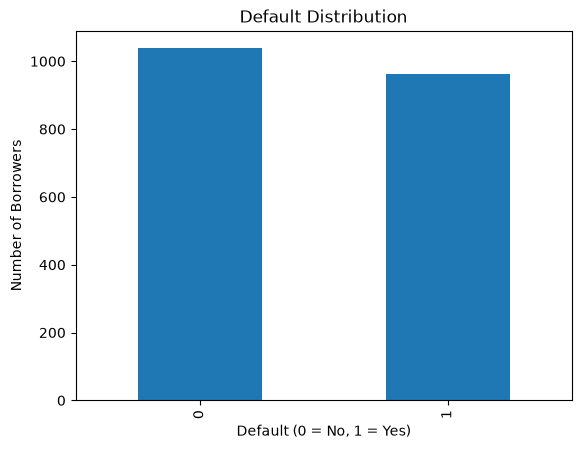

In [9]:
import matplotlib.pyplot as plt

# Default distribution
default_counts = data["default"].value_counts().sort_index()

print(default_counts)
print("\nDefault rate:", round(data["default"].mean() * 100, 2), "%")

default_counts.plot(kind="bar")
plt.title("Default Distribution")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Number of Borrowers")
plt.show()

In [10]:
data.groupby("default")["credit_score"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
default,,,,
0,685.537226,687.966831,476.002081,850.0
1,670.813455,673.566946,457.630733,850.0


In [11]:
# Credit score by default status

credit_score_summary = data.groupby("default")["credit_score"].agg(
    ["mean", "median", "min", "max"]
)

credit_score_summary

,mean,median,min,max
default,,,,
0,685.537226,687.966831,476.002081,850.0
1,670.813455,673.566946,457.630733,850.0


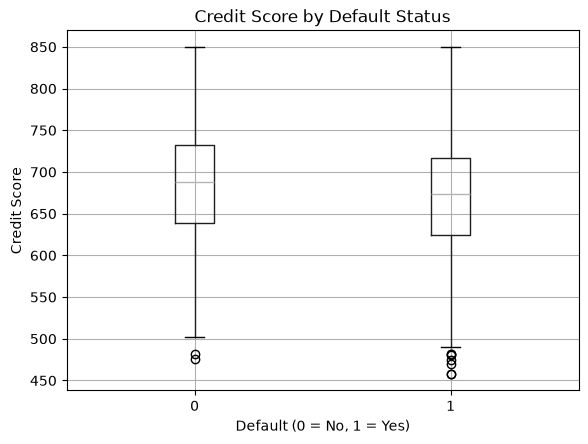

In [13]:
# Credit score distribution by default status

data.boxplot(
    column="credit_score",
    by="default"
)

plt.title("Credit Score by Default Status")
plt.suptitle("")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Credit Score")
plt.show()

In [14]:
# Compare financial characteristics by default status

financial_summary = data.groupby("default")[
    ["income", "loan_amount", "existing_debt", "late_payments"]
].mean()

financial_summary

,income,loan_amount,existing_debt,late_payments
default,,,,
0,62575.437967,23574.170345,15073.878414,0.849711
1,59257.863564,26145.771601,16083.080207,1.145530


In [15]:
# Feature Engineering: Debt-to-Income Ratio

data["debt_to_income"] = data["existing_debt"] / data["income"]

data[[
    "income",
    "existing_debt",
    "debt_to_income"
]].head()

,income,existing_debt,debt_to_income
0,69934.283060,12168.481151,0.173999
1,57234.713977,0.000000,0.000000
2,72953.770762,16580.938986,0.227280
3,90460.597128,15334.434680,0.169515
4,55316.932506,14181.056204,0.256360


In [16]:
data.groupby("default")["debt_to_income"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
default,,,,
0,0.274116,0.234098,0.0,2.995207
1,0.315920,0.259366,0.0,1.918286


In [18]:
from sklearn.model_selection import train_test_split

# Features and target
X = data.drop(columns=["default"])
y = data["default"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining default rate:", round(y_train.mean() * 100, 2), "%")
print("Testing default rate:", round(y_test.mean() * 100, 2), "%")

Training set: (1600, 8)
Testing set: (400, 8)

Training default rate: 48.12 %
Testing default rate: 48.0 %


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [20]:
# Train the credit-risk classification model

model_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [21]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Generate predictions
y_pred = model_pipeline.predict(X_test)

# Generate default probabilities
y_prob = model_pipeline.predict_proba(X_test)[:, 1]

# Model performance
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", round(auc, 4))
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))

ROC-AUC: 0.6619
Accuracy: 0.62
Precision: 0.6299
Recall: 0.5052
F1 Score: 0.5607


In [22]:
gini = 2 * auc - 1

print("Gini coefficient:", round(gini, 4))

Gini coefficient: 0.3239
